In [2]:
#Parte 2 de la tarea

In [3]:
from pathlib import Path
import os

os.chdir(Path.cwd().parent)

In [4]:
import numpy as np
import pandas as pd
import random as random
import matplotlib.pyplot as plt
from src.funciones import media_muestral
from src.funciones import varianza_muestral

In [5]:
semilla = 223
rng = np.random.default_rng(semilla)

Para estimar la media y varianza de las $Poiss(\nu)$ se proponen los estimadores $\overline{X}_n=\frac{1}{n}\sum_{i=1}^n X_i$ y $S_n^2=\frac{1}{n-1}\sum_{i=1}^n(X_i-\overline{X}_n)^2$ respectivamente. <br>
Veamos que son insesgados y consistentes: <br>
Para $\overline{X}_n$: $$\mathbb{E}[\overline{X}_n]=\mathbb{E}[\frac{1}{n}\sum_{i=1}^n X_i]$$

Tomando $\lambda = 100$ y $\mu=10$, tendremos que $\nu=\frac{\lambda}{\mu}=10$ <br>
Simulemos 1000 lanzamientos de la v.a. $Poiss(\nu)$

In [6]:
n=1000

rs_poisson= rng.poisson(lam=10,size=n)

Calculemos sus estimadores de media y varianza para cada valor de $n$

In [7]:
med_poiss= np.zeros(n)
for i in range(len(med_poiss)):
    med_poiss[i]= media_muestral(i, rs_poisson)

var_poiss= np.zeros(n)
for i in range(len(var_poiss)):
    var_poiss[i]= varianza_muestral(i, rs_poisson)


/opt/miniconda3/envs/tareas_estadistica/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/tareas_estadistica/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/miniconda3/envs/tareas_estadistica/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:4270: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/miniconda3/envs/tareas_estadistica/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/miniconda3/envs/tareas_estadistica/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcoun

Los datos se pueden visualizar de la siguiente manera:

<positron-console-cell-8>:8: SyntaxWarning: invalid escape sequence '\o'
<positron-console-cell-8>:9: SyntaxWarning: invalid escape sequence '\o'


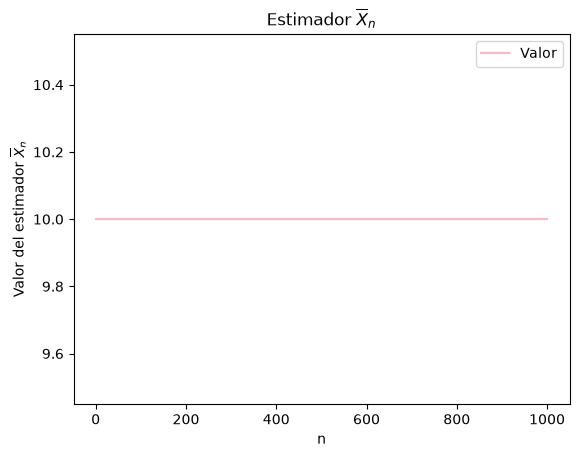

In [8]:
cantidad= np.arange(1, n +1)

nu= np.full(n,10)


plt.plot(cantidad, nu, color="lightpink",label="Valor")
plt.xlabel("n")
plt.ylabel("Valor del estimador $\overline{X}_n$")
plt.title("Estimador $\overline{X}_n$")
plt.legend()
plt.savefig("results/estimador_media_muestral_poiss.png")
plt.show()

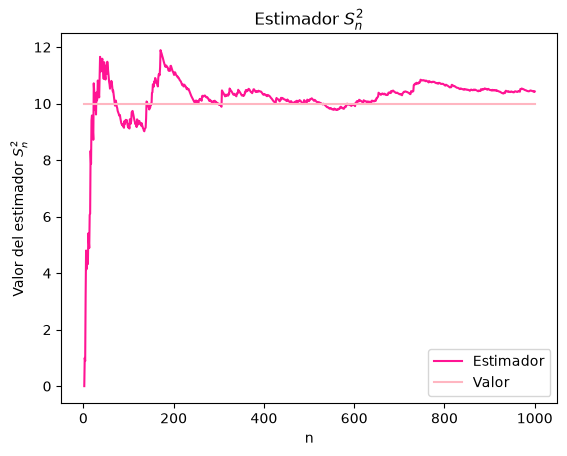

In [9]:
plt.plot(cantidad, var_poiss, color="deeppink",label="Estimador")
plt.plot(cantidad, nu, color="lightpink",label="Valor")
plt.xlabel("n")
plt.ylabel("Valor del estimador $S_n^2$")
plt.title("Estimador $S_n^2$")
plt.legend()
plt.savefig("results/estimador_var_muestral_poiss.png")
plt.show()

Como ambos estiman el mismo parametro, $\nu$, los podemos comparar:

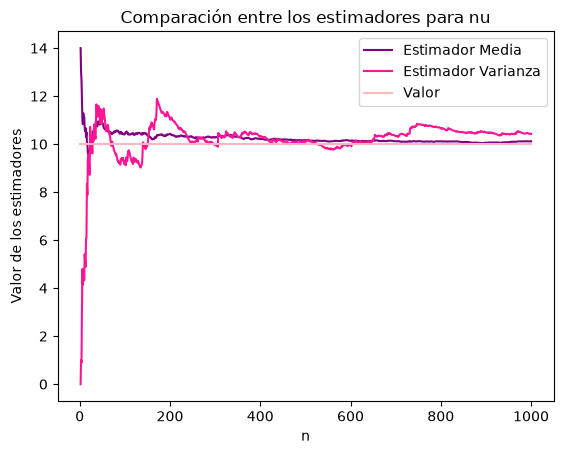

In [15]:
plt.plot(cantidad, med_poiss, color="purple",label="Estimador Media")
plt.plot(cantidad, var_poiss, color="deeppink",label="Estimador Varianza")
plt.plot(cantidad, nu, color="lightpink",label="Valor")
plt.xlabel("n")
plt.ylabel("Valor de los estimadores")
plt.title("Comparación entre los estimadores para nu")
plt.legend()
plt.savefig("results/comparacion_estimadores_poisson.png")
plt.show()

Para estimar la probabilidad del sistema vacío $\mathbb{P}(X=0)$ se proponen los siguientes estimadores: <br>
i) $\hat{g}_n^{(1)}=\exp(-\overline{X}_n)$, <br>
ii) $\hat{g}_n^{(2)}=\frac{1}{n} \sum_{i=1}^n\mathbf{1}_{X_i=0}$, <br>
iii) $\hat{g}_n^{(3)}=\exp(-S_n^2)$. <br>

In [22]:
g1 = np.exp(med_poiss)

g2 = np.zeros(n)
g2_aux = np.zeros(n)
if rs_poisson[1]== 0:
    g2_aux=1
    g2 = g2_aux
for i in range(2, n):
    if rs_poisson[i] == 0:
        g2_aux[i] = g2_aux[i-1] + 1
    else:
        g2_aux[i] = g2_aux[i-1]
    g2 = g2_aux/i

g3 = np.exp(var_poiss)

valor_g_nu = np.full(n, np.exp(-10))

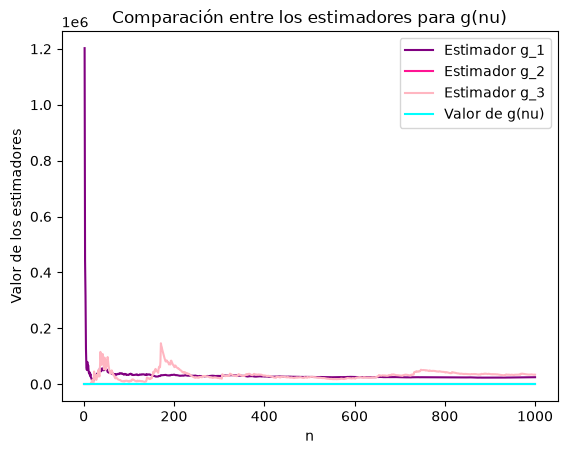

In [23]:
plt.plot(cantidad, g1, color="purple",label="Estimador g_1")
plt.plot(cantidad, g2, color="deeppink",label="Estimador g_2")
plt.plot(cantidad, g3, color="lightpink",label="Estimador g_3")
plt.plot(cantidad, valor_g_nu, color="cyan", label="Valor de g(nu)")
plt.xlabel("n")
plt.ylabel("Valor de los estimadores")
plt.title("Comparación entre los estimadores para g(nu)")
plt.legend()
plt.savefig("results/comparacion_estimadores_g(nu).png")
plt.show()